## Ejercicio 1: Evaluación de solicitud de crédito bancario

### Ficha PEAS

| Elemento | Descripción |
|---|---|
| **Percepción (S)** | Ingreso mensual, monto solicitado, historial moroso y relación entre el monto solicitado y el ingreso mensual. |
| **Acciones (A)** | Aprobar, aprobar con condiciones o rechazar la solicitud de crédito. |
| **Entorno (E)** | Banco, clientes solicitantes de crédito, historial financiero y sistema de evaluación crediticia. |
| **Objetivo** | Evaluar el riesgo de la solicitud y otorgar créditos a clientes que tengan capacidad de pago. |
| **Medida de desempeño (P)** | Reducir el riesgo de morosidad, aprobar solicitudes viables y evitar rechazos innecesarios. |

### Justificación de las reglas

Se utilizarán las siguientes reglas de decisión:

- Si no tiene historial moroso y la relación monto/ingreso es menor o igual a 0.30, se aprueba el crédito.
- Si no tiene historial moroso y la relación es mayor a 0.30 pero menor o igual a 0.50, se aprueba con condiciones.
- Si no tiene historial moroso y la relación es mayor a 0.50, se rechaza la solicitud.
- Si tiene historial moroso y la relación es menor o igual a 0.30, se aprueba con condiciones.
- Si tiene historial moroso y la relación es mayor a 0.30, se rechaza la solicitud.

Estas reglas consideran la capacidad de pago del solicitante y su comportamiento crediticio previo. Una relación monto/ingreso baja representa un menor riesgo para el banco, mientras que una relación alta aumenta la posibilidad de incumplimiento. Además, tener historial moroso incrementa el nivel de riesgo, por lo que se aplican condiciones más estrictas al momento de tomar la decisión.

### Código

In [1]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    relacion = monto_solicitado / ingreso_mensual

    if tiene_historial_moroso:
        if relacion <= 0.30:
            return "aprobar con condiciones", "relación baja, pero presenta historial moroso"
        else:
            return "rechazar", "presenta historial moroso y la relación monto/ingreso es mayor a 0.30"

    else:
        if relacion <= 0.30:
            return "aprobar", "no presenta historial moroso y la relación monto/ingreso es menor o igual a 0.30"
        elif relacion <= 0.50:
            return "aprobar con condiciones", "no presenta historial moroso, pero la relación monto/ingreso está entre 0.30 y 0.50"
        else:
            return "rechazar", "la relación monto/ingreso es mayor a 0.50"

### Simulación y pruebas

In [2]:
casos_prueba = [
    (3000, 600, False),    # relación = 0.20
    (3000, 900, False),    # relación = 0.30 -> caso límite
    (3000, 1200, False),   # relación = 0.40
    (3000, 1500, False),   # relación = 0.50 -> caso límite
    (3000, 1800, False),   # relación = 0.60
    (3000, 600, True),     # relación = 0.20 con historial moroso
    (3000, 1200, True)     # relación = 0.40 con historial moroso
]

for ingreso, monto, moroso in casos_prueba:
    accion, motivo = agente_credito(ingreso, monto, moroso)
    relacion = monto / ingreso

    print("Ingreso mensual:", ingreso)
    print("Monto solicitado:", monto)
    print("Relación monto/ingreso:", round(relacion, 2))
    print("Historial moroso:", moroso)
    print("Decisión:", accion)
    print("Motivo:", motivo)
    print("-" * 50)

Ingreso mensual: 3000
Monto solicitado: 600
Relación monto/ingreso: 0.2
Historial moroso: False
Decisión: aprobar
Motivo: no presenta historial moroso y la relación monto/ingreso es menor o igual a 0.30
--------------------------------------------------
Ingreso mensual: 3000
Monto solicitado: 900
Relación monto/ingreso: 0.3
Historial moroso: False
Decisión: aprobar
Motivo: no presenta historial moroso y la relación monto/ingreso es menor o igual a 0.30
--------------------------------------------------
Ingreso mensual: 3000
Monto solicitado: 1200
Relación monto/ingreso: 0.4
Historial moroso: False
Decisión: aprobar con condiciones
Motivo: no presenta historial moroso, pero la relación monto/ingreso está entre 0.30 y 0.50
--------------------------------------------------
Ingreso mensual: 3000
Monto solicitado: 1500
Relación monto/ingreso: 0.5
Historial moroso: False
Decisión: aprobar con condiciones
Motivo: no presenta historial moroso, pero la relación monto/ingreso está entre 0.30 y 

### Visualización

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

cantidad_solicitudes = 200

ingresos = np.random.randint(1000, 10001, cantidad_solicitudes)
montos = np.random.randint(200, 8001, cantidad_solicitudes)
historiales = np.random.choice(
    [True, False],
    size=cantidad_solicitudes
)

relaciones = []
decisiones = []

for ingreso, monto, moroso in zip(ingresos, montos, historiales):
    relacion = monto / ingreso
    accion, motivo = agente_credito(ingreso, monto, moroso)

    relaciones.append(relacion)
    decisiones.append(accion)

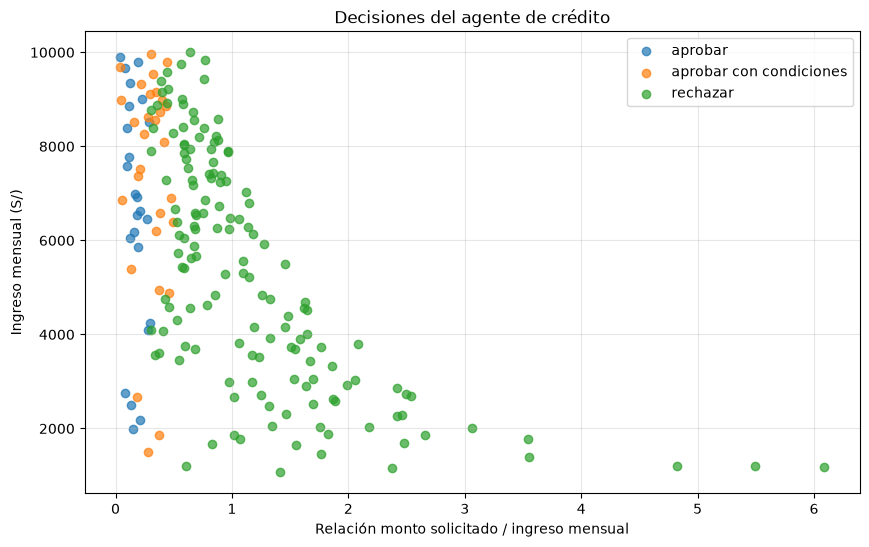

In [4]:
relaciones = np.array(relaciones)
decisiones = np.array(decisiones)

plt.figure(figsize=(10, 6))

for accion in ["aprobar", "aprobar con condiciones", "rechazar"]:
    seleccion = decisiones == accion

    plt.scatter(
        relaciones[seleccion],
        ingresos[seleccion],
        label=accion,
        alpha=0.7
    )

plt.xlabel("Relación monto solicitado / ingreso mensual")
plt.ylabel("Ingreso mensual (S/)")
plt.title("Decisiones del agente de crédito")
plt.legend()
plt.grid(alpha=0.3)
plt.show()